[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Data-Crew/transport-networks-lab/blob/main/Notebooks/Ejercitacion_IntroNx.ipynb)


#  Grafos y redes de transporte con `NetworkX`

## **Clases de grafos - Ejercitación**

* Crear una representacion alternativa de la red de subtes que vimos en la práctica guiada. Para ello, deberán convertir un grafo no dirigido en uno dirigido y distribuir los pasajeros en ambas direcciones.   

In [1]:
from google.colab import drive
drive.mount('/drive/')

Mounted at /drive/


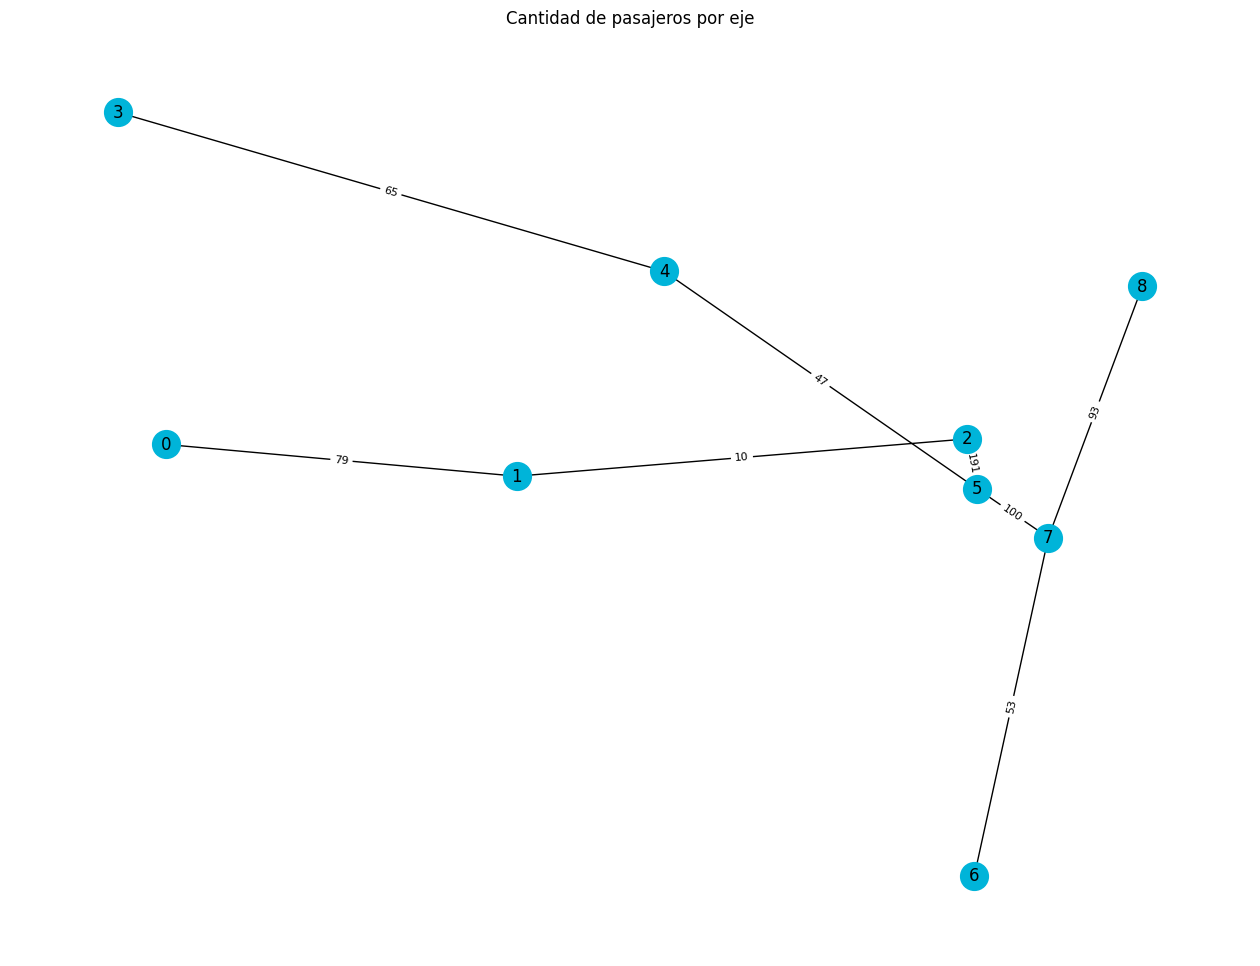

In [2]:
#@title Funcionalidades para crear una red de juguete

# importar libreria
import networkx as nx
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt


def crear_grafo():
    '''
    Crea un grafo no dirigido
    '''
    G = nx.Graph()

    nodos = list(range(9))
    G.add_nodes_from(nodos)

    for n in range(0, len(nodos), 3):
        G.add_edge(n, n+1)
        G.add_edge(n+1, n+2)

    desconectados = [(2, 5), (7, 5)]
    for u, v in desconectados:
        G.add_edge(u, v)

    return G


def atributos_para_nodos():
    '''
    Prepara un diccionario con atributos de algunas estaciones del Subte de la CABA
    '''
    # completamos la primera estacion manualmente.
    G.nodes[0]['estacion'] = 'CALLAO'
    G.nodes[0]['linea'] = 'B'
    G.nodes[0]['color'] = 'red'
    G.nodes[0]['coord'] = (-58.39241446187341, -34.603705218144896)

    # y el resto con el dataset
    subte = pd.read_csv('/drive/MyDrive/Técnicas y Análisis de datos del Transporte/Data/estaciones-de-subte.csv')
    lineas = subte[subte.linea.isin(['C','B','D'])]

    estaciones = lineas[lineas.estacion.isin(['URUGUAY', 'C. PELLEGRINI',
                                              '9 DE JULIO', 'CALLAO',  'TRIBUNALES - TEATRO COLÓN',
                                              'AV. DE MAYO', 'DIAGONAL NORTE', 'LAVALLE'])].copy()

    estaciones['coord'] = list(zip(estaciones.long, estaciones.lat))

    estaciones = estaciones.sort_values(by=['linea','id'], ascending=False)
    estaciones_reorder = []
    for l in ['B','D','C']:
        estaciones_reorder.append(estaciones[estaciones.linea==l])

    estaciones = pd.concat(estaciones_reorder).reset_index().drop(columns='index')
    estaciones['node_idx'] = list(range(1, len(estaciones)+1))
    estaciones['color'] = estaciones.linea.replace({'D':'green', 'C':'blue', 'B':'red'})
    estaciones.set_index(estaciones.estacion, inplace=True)
    estaciones.drop(columns=['estacion','id', 'long', 'lat'], inplace=True)

    atributos = estaciones.to_dict(orient='index')

    return atributos

def define_atributos_nodos(atributos, nombre_estacion):
    '''
    Utiliza un diccionario de atritbutos para poblar los nodos de un grafo
    '''
    G.nodes[atributos[nombre_estacion]['node_idx']]['estacion'] = nombre_estacion
    G.nodes[atributos[nombre_estacion]['node_idx']]['linea'] = atributos[nombre_estacion]['linea']
    G.nodes[atributos[nombre_estacion]['node_idx']]['color'] = atributos[nombre_estacion]['color']
    G.nodes[atributos[nombre_estacion]['node_idx']]['coord'] = atributos[nombre_estacion]['coord']


def define_atributos_ejes():
    '''
    Define los atributos de los ejes de las tres lineas
    '''
    conexiones_lineas = [(2,5),(5,7)]
    conexiones_estaciones = [i for i in G.edges if i not in conexiones_lineas]

    for i in conexiones_estaciones:
        G.edges[i[0], i[1]]['fecha']='2019-10-01'
        G.edges[i[0], i[1]]['hora']='09:30:00'
        G.edges[i[0], i[1]]['pasajeros']=random.randint(10,100)

    for i in conexiones_lineas:
        G.edges[i[0], i[1]]['fecha']='2019-10-01'
        G.edges[i[0], i[1]]['hora']='09:30:00'
        G.edges[i[0], i[1]]['pasajeros']=random.randint(100,200)

def visualizar_grafo(G, dirigido=True):
    """
    Visualiza el grafo con los atributos de pasajeros y colores.

    Args:
    G (networkx.Graph): Grafo
    dirigido (bool): Indica si el grafo debe ser convertido a dirigido.
    """
    if dirigido:
        color_dict = nx.get_node_attributes(G, 'color')
        colors = [color_dict[n] for n in G.nodes()]
        title = 'Cantidad de pasajeros por eje (ida y vuelta)'
        connection_style = 'arc3, rad = 0.1'
    else:
        colors = '#00b4d9'
        title = 'Cantidad de pasajeros por eje'
        connection_style = None

    fig, ax = plt.subplots(figsize=(16, 12))
    pos = nx.get_node_attributes(G, 'coord')

    edge_params = {
        'pos': pos,
        'arrows': dirigido,
        'node_size': 400,
        'node_color': colors,
        'with_labels': True,
        'ax': ax
    }

    if connection_style:
        edge_params['connectionstyle'] = connection_style

    nx.draw(G, **edge_params)

    ax.set_title(title)

    edge_labels = nx.get_edge_attributes(G, 'pasajeros')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8)

    plt.show()


G = crear_grafo()
input_dict = atributos_para_nodos()

for k in input_dict.keys():
    define_atributos_nodos(atributos=input_dict, nombre_estacion=k)

define_atributos_ejes()
visualizar_grafo(G, dirigido=False)

In [ ]:
# Desarrollar ejercicio aca

Cantidad de pasajeros por eje: {(0, 1): 39.5, (1, 0): 39.5, (1, 2): 5.0, (2, 1): 5.0, (2, 5): 95.5, (3, 4): 32.5, (4, 3): 32.5, (4, 5): 23.5, (5, 4): 23.5, (5, 2): 95.5, (5, 7): 50.0, (6, 7): 26.5, (7, 6): 26.5, (7, 8): 46.5, (7, 5): 50.0, (8, 7): 46.5}
Pasajeros redondeados por eje: {(1, 0): 40, (0, 1): 39, (1, 2): 5, (2, 1): 5, (2, 5): 95, (5, 2): 96, (3, 4): 33, (4, 3): 32, (5, 4): 24, (4, 5): 23, (5, 7): 50, (7, 6): 27, (6, 7): 26, (8, 7): 46, (7, 8): 47, (7, 5): 50}



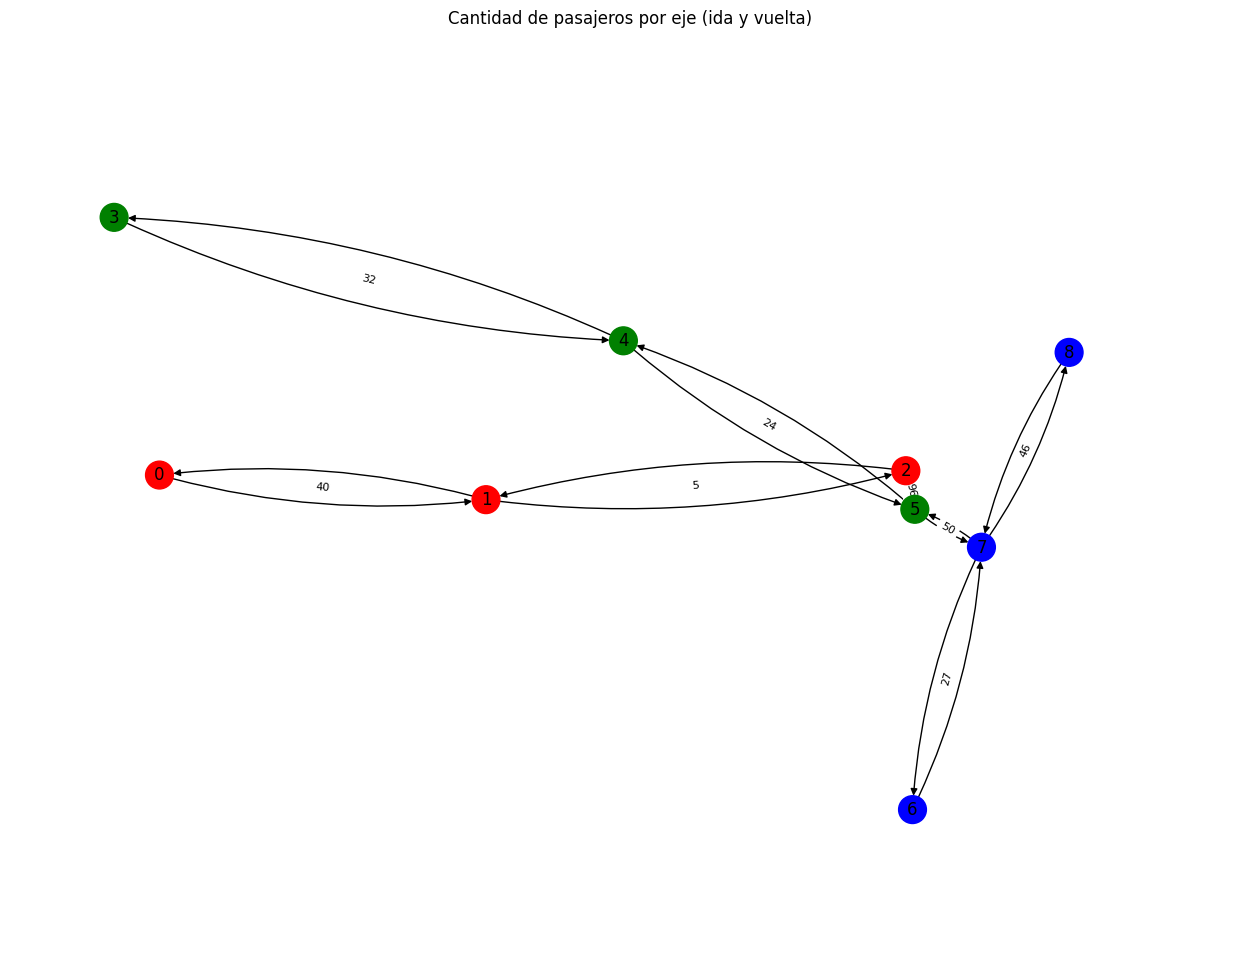

In [3]:
#@title **Solución:** modificamos la representación de la red `(G -> GD)`
GD = G.to_directed()

# Distribuimos y redondeamos la cantidad de pasajeros
dirigidos = {e: GD.edges[e]['pasajeros'] / 2 for e in GD.edges()}
print(f"Cantidad de pasajeros por eje: {dirigidos}")

# Redondeamos los valores de pasajeros en los ejes
redondeados = {}
for (u, v), pasajeros in dirigidos.items():
    pasajeros_base = int(pasajeros)
    resto = pasajeros - pasajeros_base

    if resto > 0:
        # asignamos el pasajero adicional aleatoriamente
        entero = int(np.ceil(resto))
        pasajero_adicional = pasajeros_base + entero
        eje_seleccionado = random.choice([(u, v), (v, u)])

        # reasignamos la cantidad de pasajeros al eje seleccionado
        redondeados[eje_seleccionado] = pasajero_adicional
        redondeados[(v, u) if eje_seleccionado == (u, v) else (u, v)] = pasajeros_base
    else:
        redondeados[(u, v)] = pasajeros_base

print(f"Pasajeros redondeados por eje: {redondeados}")

# Actualizamos el grafo dirigido con los valores redondeados
for (u, v), pasajeros in redondeados.items():
    GD.edges[u, v]['pasajeros'] = pasajeros

print('')

visualizar_grafo(GD, dirigido=True)

## **Métricas de una red - Ejercitación**

* Armar una función que devuelva:

  * el nodo con grado o centralidad de grado más altos
  * el nodo según la cantidad deseada de vecinos

In [ ]:
# Desarrollar ejercicio aca

In [4]:
#@title **Solución:** función para filtrar nodos según grado y centralidad de grado
def max_centrality(graph, metric, top_vals):
    """
    Devuelve una lista ordenada de tuplas con los nodos de mayor grado dentro de la red
    """

    # establecemos al grado a partir de la cantidad de vecinos
    degree = [(n,graph.degree(n)) for n in graph.nodes()]

    # Definimos el denominador
    nodes = graph.number_of_nodes()-1

    # y calculamos la centralidad
    centrality = [(n,graph.degree(n)/nodes) for n in graph.nodes()]

    if metric == 'degree':
        m = degree
    else:
        m = centrality

    # ordenamos la lista y obtenemos los n indices mas altos
    idx = sorted(range(len(m)), key = lambda sub: m[sub][1], reverse=True)[:top_vals]

    # filtramos la lista de tuplas con los indices mas altos
    output = [m[i] for i in idx]

    return output

# Obtenemos los nodos con mayor grado dentro de la red
print(f"Los nodos con mayor grado son: {max_centrality(graph=G, metric='degree', top_vals=2)}")

# y ahora lo mismo pero usando el degree centrality
print(f"Los nodos con mayor centralidad de grado son: {max_centrality(graph=G, metric='centrality', top_vals=2)}")

Los nodos con mayor grado son: [(5, 3), (7, 3)]
Los nodos con mayor centralidad de grado son: [(5, 0.375), (7, 0.375)]


* Armar una función que devuelva:

  * los nodos un grafo según la cantidad de vecinos

In [ ]:
# Desarrollar ejercicio aca

In [5]:
#@title **Solución:** función para obtener nodos segun la cantidad de vecinos
def nodes_with_m_nbrs(graph, m):
    """
    Devuelce los nodos con m vecinos dentro de la red.
    """
    nodes = set()

    # Iteramos sobre todos los nodos
    for n in graph.nodes():

        # chequeamos el numero de vecinos matchee con el parametro m
        if len(list(graph.neighbors(n))) == m:

            # Agregamos el nodo al set
            nodes.add(n)

    # devolvemos el nodo segun cantidad de vecinos
    return nodes

# Obtenemos los nodos con tres vecinos
tres_vecinos = nodes_with_m_nbrs(graph=G, m=3)
print(f"Los nodos con tres vecinos son: {tres_vecinos}")

Los nodos con tres vecinos son: {5, 7}


## **Distancias y búsqueda de caminos - Ejercitación**

* Armar una función que devuelva el/los nodo/s con mayor centralidad de intermediación (`betweenness centrality`) dentro de una red.

In [ ]:
# Desarrollar ejercicio

In [6]:
#@title **Solución:** función para encontrar los nodos con mayor centralidad de intermediación

def mayor_intermediacion(grafo):
    '''
    Devuelve el/los nodos con mayor centralidad de intermediación dentro de un grafo
    '''
    intermediacion = nx.betweenness_centrality(grafo)
    max_int = max(intermediacion.values())
    nodos = {k for k, v in intermediacion.items() if v == max_int}
    return nodos, max_int

nodos, intermediacion = mayor_intermediacion(grafo=G)

print(f"El/los nodo/s con mayor centralidad de intermediacion son: {nodos}")
print(f"El/los mayores valores de intermediacion son: {intermediacion}")

El/los nodo/s con mayor centralidad de intermediacion son: {5}
El/los mayores valores de intermediacion son: 0.75
